# Metals Trade Size Histogram By Hour

This notebook aggregates raw 3-year metals trade prints into trade-size histograms by UTC hour. It uses the canonical trade source:

`/home/famadeo/research/databento-asset-browser/data/metals_trades_3y_core/outright`

The plots use contract `size`, not notional. Aggressor side is not used here.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

plt.style.use("seaborn-v0_8-whitegrid")

TRADE_DIR = Path("/home/famadeo/research/databento-asset-browser/data/metals_trades_3y_core/outright")
ROOTS = ["GC", "SI", "HG", "PL", "PA"]
ASSET_DIR = Path("assets/2026-06-25_metals_trade_size_by_hour")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

BUCKET_ORDER = [
    "001: 1",
    "002: 2",
    "003: 3-5",
    "004: 6-10",
    "005: 11-25",
    "006: 26-50",
    "007: 51-100",
    "008: 101-250",
    "009: 251-500",
    "010: >500",
]

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 40)

In [3]:
paths = {root: TRADE_DIR / f"{root}.parquet" for root in ROOTS}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing trade files: {missing}")

inventory = []
for root, path in paths.items():
    row = (
        pl.scan_parquet(path)
        .select(
            pl.len().alias("rows"),
            pl.col("ts_event").min().alias("min_ts"),
            pl.col("ts_event").max().alias("max_ts"),
            pl.col("size").min().alias("min_size"),
            pl.col("size").max().alias("max_size"),
        )
        .collect()
        .to_dicts()[0]
    )
    inventory.append({"root": root, **row})

inventory = pd.DataFrame(inventory)
inventory

,root,rows,min_ts,max_ts,min_size,max_size
0,GC,82365734,2023-06-22 00:00:04.064891+00:00,2026-06-21 23:59:56.082051+00:00,1.0,499.0
1,SI,29540740,2023-06-22 00:00:03.966970+00:00,2026-06-21 23:59:52.143142+00:00,1.0,525.0
2,HG,25318855,2023-06-22 00:00:00.162726+00:00,2026-06-21 23:59:56.506287+00:00,1.0,548.0
3,PL,13719194,2023-06-22 00:01:10.756358+00:00,2026-06-21 23:58:25.144921+00:00,1.0,327.0
4,PA,2386009,2023-06-22 00:33:24.040162+00:00,2026-06-21 23:55:48.277942+00:00,1.0,126.0


In [4]:
def size_bucket_expr() -> pl.Expr:
    size = pl.col("size")
    return (
        pl.when(size <= 1).then(pl.lit("001: 1"))
        .when(size <= 2).then(pl.lit("002: 2"))
        .when(size <= 5).then(pl.lit("003: 3-5"))
        .when(size <= 10).then(pl.lit("004: 6-10"))
        .when(size <= 25).then(pl.lit("005: 11-25"))
        .when(size <= 50).then(pl.lit("006: 26-50"))
        .when(size <= 100).then(pl.lit("007: 51-100"))
        .when(size <= 250).then(pl.lit("008: 101-250"))
        .when(size <= 500).then(pl.lit("009: 251-500"))
        .otherwise(pl.lit("010: >500"))
        .alias("size_bucket")
    )


lazy_parts = []
for root, path in paths.items():
    lazy_parts.append(
        pl.scan_parquet(path)
        .select(
            pl.lit(root).alias("root"),
            pl.col("ts_event").dt.hour().alias("hour_utc"),
            pl.col("size").cast(pl.Float64).alias("size"),
        )
        .with_columns(size_bucket_expr())
        .group_by("root", "hour_utc", "size_bucket")
        .agg(
            pl.len().alias("trades"),
            pl.col("size").sum().alias("contracts"),
            pl.col("size").mean().alias("mean_size"),
        )
    )

hist = pl.concat(lazy_parts).collect().to_pandas()
hist["hour_utc"] = hist["hour_utc"].astype(int)
hist["size_bucket"] = pd.Categorical(hist["size_bucket"], BUCKET_ORDER, ordered=True)
hist = hist.sort_values(["root", "hour_utc", "size_bucket"]).reset_index(drop=True)

root_hour_total = hist.groupby(["root", "hour_utc"], observed=True)["trades"].transform("sum")
hist["share_within_root_hour"] = hist["trades"] / root_hour_total
hist.to_csv(ASSET_DIR / "trade_size_histogram_by_hour.csv", index=False)
hist.head(20)

,root,hour_utc,size_bucket,trades,contracts,mean_size,share_within_root_hour
0,GC,0,001: 1,1498666,1498666.0,1.000000,7.303426e-01
1,GC,0,002: 2,309428,618856.0,2.000000,1.507931e-01
2,GC,0,003: 3-5,195503,698982.0,3.575301,9.527418e-02
3,GC,0,004: 6-10,38807,281628.0,7.257144,1.891176e-02
4,GC,0,005: 11-25,8576,125343.0,14.615555,4.179329e-03
5,GC,0,006: 26-50,813,27584.0,33.928659,3.961981e-04
6,GC,0,007: 51-100,156,10489.0,67.237179,7.602324e-05
7,GC,0,008: 101-250,53,7261.0,137.000000,2.582841e-05
8,GC,0,009: 251-500,2,652.0,326.000000,9.746570e-07
9,GC,1,001: 1,2622351,2622351.0,1.000000,7.424258e-01


In [5]:
overall = (
    hist.groupby(["hour_utc", "size_bucket"], observed=True, as_index=False)
    .agg(trades=("trades", "sum"), contracts=("contracts", "sum"))
)
overall_total = overall.groupby("hour_utc", observed=True)["trades"].transform("sum")
overall["share_within_hour"] = overall["trades"] / overall_total
overall.to_csv(ASSET_DIR / "overall_trade_size_histogram_by_hour.csv", index=False)

overall.pivot_table(
    index="hour_utc",
    columns="size_bucket",
    values="share_within_hour",
    aggfunc="sum",
    observed=True,
).reindex(index=range(24), columns=BUCKET_ORDER).fillna(0.0).style.format("{:.2%}")

size_bucket,001: 1,002: 2,003: 3-5,004: 6-10,005: 11-25,006: 26-50,007: 51-100,008: 101-250,009: 251-500,010: >500
hour_utc,,,,,,,,,,
0,73.46%,15.20%,9.00%,1.84%,0.44%,0.04%,0.01%,0.00%,0.00%,0.00%
1,73.84%,15.54%,8.45%,1.70%,0.42%,0.04%,0.01%,0.00%,0.00%,0.00%
2,73.35%,15.48%,8.86%,1.82%,0.44%,0.04%,0.01%,0.00%,0.00%,0.00%
3,73.34%,15.38%,9.00%,1.81%,0.42%,0.03%,0.01%,0.00%,0.00%,0.00%
4,72.61%,15.47%,9.45%,1.97%,0.45%,0.03%,0.01%,0.00%,0.00%,0.00%
5,73.19%,15.63%,8.92%,1.80%,0.42%,0.03%,0.01%,0.00%,0.00%,0.00%
6,72.57%,15.77%,9.23%,1.90%,0.48%,0.04%,0.01%,0.00%,0.00%,0.00%
7,70.93%,16.32%,9.94%,2.20%,0.57%,0.04%,0.01%,0.00%,0.00%,0.00%
8,70.73%,16.31%,9.99%,2.28%,0.63%,0.05%,0.01%,0.00%,0.00%,0.00%


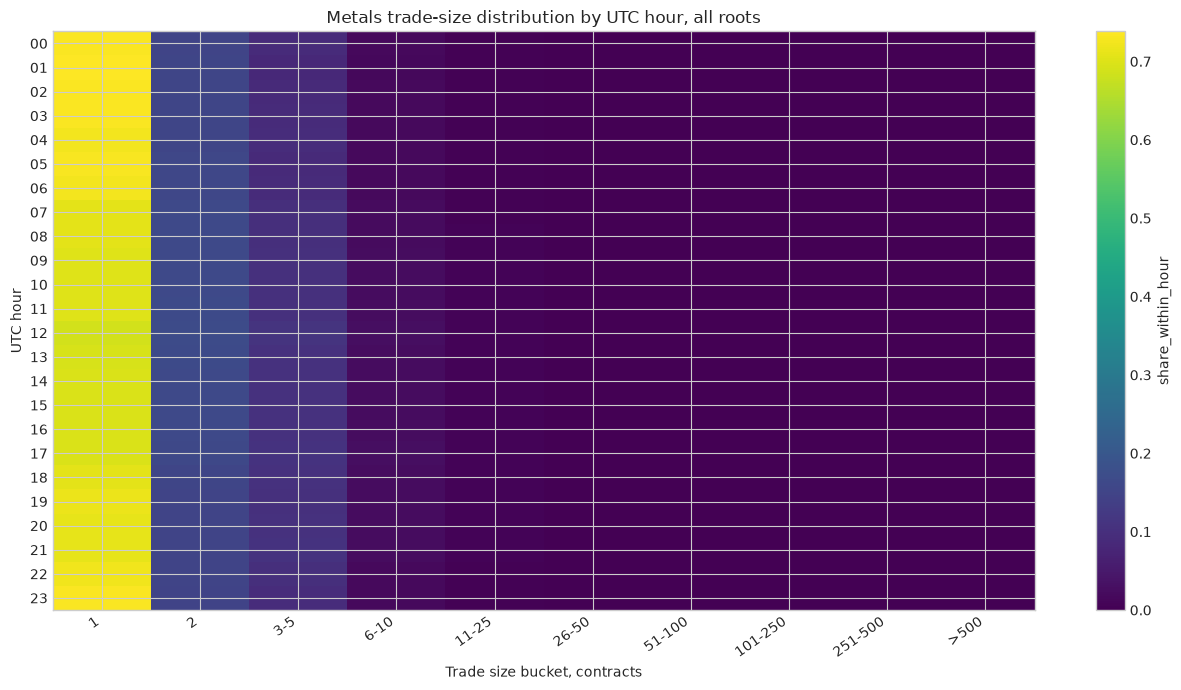

In [6]:
def plot_hour_bucket_heatmap(frame: pd.DataFrame, value_col: str, title: str, path: Path) -> None:
    matrix = (
        frame.pivot_table(
            index="hour_utc",
            columns="size_bucket",
            values=value_col,
            aggfunc="sum",
            observed=True,
        )
        .reindex(index=range(24), columns=BUCKET_ORDER)
        .fillna(0.0)
    )
    fig, ax = plt.subplots(figsize=(13, 7))
    image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Trade size bucket, contracts")
    ax.set_ylabel("UTC hour")
    ax.set_xticks(np.arange(len(BUCKET_ORDER)))
    ax.set_xticklabels([label.split(": ", 1)[1] for label in BUCKET_ORDER], rotation=35, ha="right")
    ax.set_yticks(np.arange(24))
    ax.set_yticklabels([f"{hour:02d}" for hour in range(24)])
    fig.colorbar(image, ax=ax, label=value_col)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()


plot_hour_bucket_heatmap(
    overall,
    "share_within_hour",
    "Metals trade-size distribution by UTC hour, all roots",
    ASSET_DIR / "overall_trade_size_share_by_hour.png",
)

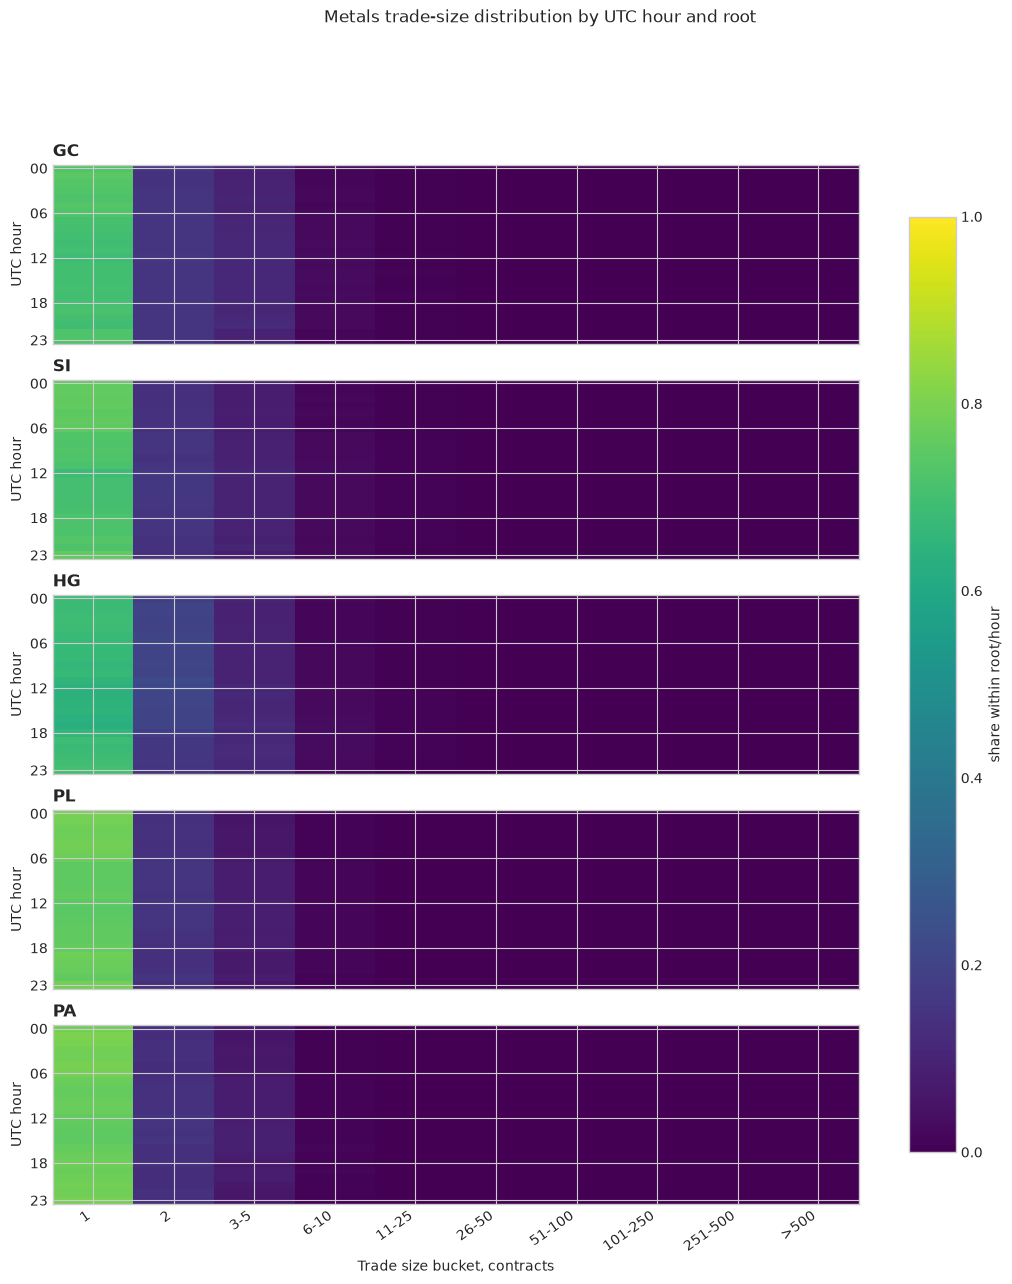

In [7]:
fig, axes = plt.subplots(len(ROOTS), 1, figsize=(13, 2.7 * len(ROOTS)), sharex=True)
if len(ROOTS) == 1:
    axes = [axes]

for ax, root in zip(axes, ROOTS, strict=True):
    root_frame = hist.loc[hist["root"] == root]
    matrix = (
        root_frame.pivot_table(
            index="hour_utc",
            columns="size_bucket",
            values="share_within_root_hour",
            aggfunc="sum",
            observed=True,
        )
        .reindex(index=range(24), columns=BUCKET_ORDER)
        .fillna(0.0)
    )
    image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_title(root, loc="left", fontweight="bold")
    ax.set_ylabel("UTC hour")
    ax.set_yticks([0, 6, 12, 18, 23])
    ax.set_yticklabels(["00", "06", "12", "18", "23"])

axes[-1].set_xlabel("Trade size bucket, contracts")
axes[-1].set_xticks(np.arange(len(BUCKET_ORDER)))
axes[-1].set_xticklabels([label.split(": ", 1)[1] for label in BUCKET_ORDER], rotation=35, ha="right")
fig.colorbar(image, ax=axes, label="share within root/hour", shrink=0.9)
fig.suptitle("Metals trade-size distribution by UTC hour and root", y=0.995)
#fig.tight_layout()
fig.savefig(ASSET_DIR / "per_root_trade_size_share_by_hour.png", dpi=160)
plt.show()

In [8]:
summary = (
    hist.groupby(["root", "hour_utc"], observed=True, as_index=False)
    .agg(
        trades=("trades", "sum"),
        contracts=("contracts", "sum"),
    )
    .assign(mean_trade_size=lambda df: df["contracts"] / df["trades"])
    .sort_values(["root", "hour_utc"])
)
summary.to_csv(ASSET_DIR / "trade_size_hour_summary.csv", index=False)
summary.pivot(index="hour_utc", columns="root", values="mean_trade_size").round(2)

root,GC,HG,PA,PL,SI
hour_utc,,,,,
0,1.59,1.68,1.36,1.38,1.58
1,1.56,1.63,1.33,1.39,1.55
2,1.59,1.63,1.34,1.41,1.57
3,1.60,1.62,1.36,1.42,1.55
4,1.63,1.63,1.36,1.41,1.59
5,1.59,1.64,1.36,1.41,1.55
6,1.61,1.67,1.36,1.44,1.58
7,1.68,1.68,1.41,1.50,1.67
8,1.70,1.70,1.43,1.50,1.70
